In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ankushpanjiyar/particle-collision-track-reconstruction/QCDToGGQQ_IMGjet_RH1all_jet0_run0_n36272.test.snappy.parquet
/kaggle/input/datasets/ankushpanjiyar/particle-collision-track-reconstruction/QCDToGGQQ_IMGjet_RH1all_jet0_run1_n47540.test.snappy.parquet
/kaggle/input/datasets/ankushpanjiyar/particle-collision-track-reconstruction/QCDToGGQQ_IMGjet_RH1all_jet0_run2_n55494.test.snappy.parquet


# Graph Neural Networks for Jet Classification (Run2 Dataset)

This notebook evaluates graph-based models on a third independent dataset split (jet0 run2) to further analyze model consistency and robustness.

## Motivation

Previous experiments (run0 and run1) showed that model performance varies across dataset splits. 

To better understand this variability, we evaluate the same pipeline on a third dataset (run2). This allows us to assess whether observed trends persist across multiple independent samples.

In [2]:
!pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 17.8 MB/s eta 0:00:0000:0100:01


In [3]:
import torch
import torch.nn.functional as F
from torch.nn import Linear, Sequential, ReLU
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATConv, EdgeConv, global_mean_pool
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
import pyarrow.parquet as pq

In [4]:
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

## Experimental Setup

The preprocessing pipeline, graph construction method, and model architectures are kept identical to previous experiments.

This ensures that any performance differences arise solely from variations in the dataset and not from changes in methodology.

In [5]:
file = "/kaggle/input/datasets/ankushpanjiyar/particle-collision-track-reconstruction/QCDToGGQQ_IMGjet_RH1all_jet0_run2_n55494.test.snappy.parquet"

pf= pq.ParquetFile(file)
print("rows:", pf.metadata.num_rows)
print("columns:", pf.schema.names)

rows: 55494
columns: ['item', 'pt', 'm0', 'y']


In [6]:
def jet_to_particles(jet):

    jet_array = np.array([np.stack(jet[i]) for i in range(3)])
    pt_image = jet_array[0]
    rows, cols = np.where(pt_image > 0)
    
    pt  = jet_array[0, rows, cols]
    eta = jet_array[1, rows, cols]
    phi = jet_array[2, rows, cols]

    # --- Derived features ---
    eta_center = np.mean(eta)
    phi_center = np.mean(phi)
    deta = eta - eta_center
    dphi = phi - phi_center
    dr = np.sqrt(deta**2 + dphi**2)
    log_pt = np.log(pt + 1e-6)

    # --- Stack features ---
    particles = np.stack([
        pt,
        log_pt,
        eta,
        phi,
        deta,
        dphi,
        dr
    ], axis=1)
    return particles

def normalize_features(particles):
    mean = particles.mean(axis=0)
    std  = particles.std(axis=0) + 1e-6
    particles = (particles - mean) / std
    return particles

def build_knn_graph(particles, k=8):
    coords = particles[:, 2:4]
    num_nodes = len(coords)
    # Ensure valid k
    k = min(k, num_nodes-1)

    nbrs = NearestNeighbors(n_neighbors=k)
    nbrs.fit(coords)
    _, indices = nbrs.kneighbors(coords)
    edges = []

    for i in range(num_nodes):
        for j in indices[i]:
            if i != j:   # remove self-loop
                edges.append([i, j])

    return np.array(edges)

def create_graph_data(particles, edges, label):
    x = torch.tensor(particles, dtype=torch.float)
    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    y = torch.tensor([label], dtype=torch.long)
    return Data(x=x, edge_index=edge_index, y=y)

In [7]:
dataset_knn = []
batch_size = 500  

for batch in pf.iter_batches(batch_size=batch_size):
    df_batch = batch.to_pandas()
    for i in range(len(df_batch)):

        jet = df_batch.iloc[i]["X_jets"]
        label = int(df_batch.iloc[i]["y"])
        particles = jet_to_particles(jet)

        if len(particles) < 5:
            continue

        particles = normalize_features(particles)
        edges = build_knn_graph(particles, k=8)
        graph = create_graph_data(particles, edges, label)
        dataset_knn.append(graph)

    print(f"Processed: {len(dataset_knn)} graphs")
 

Processed: 500 graphs
Processed: 1000 graphs
Processed: 1500 graphs
Processed: 2000 graphs
Processed: 2500 graphs
Processed: 3000 graphs
Processed: 3500 graphs
Processed: 4000 graphs
Processed: 4500 graphs
Processed: 5000 graphs
Processed: 5500 graphs
Processed: 6000 graphs
Processed: 6500 graphs
Processed: 7000 graphs
Processed: 7500 graphs
Processed: 8000 graphs
Processed: 8500 graphs
Processed: 9000 graphs
Processed: 9500 graphs
Processed: 10000 graphs
Processed: 10500 graphs
Processed: 11000 graphs
Processed: 11500 graphs
Processed: 12000 graphs
Processed: 12500 graphs
Processed: 13000 graphs
Processed: 13500 graphs
Processed: 14000 graphs
Processed: 14500 graphs
Processed: 15000 graphs
Processed: 15500 graphs
Processed: 16000 graphs
Processed: 16500 graphs
Processed: 17000 graphs
Processed: 17500 graphs
Processed: 18000 graphs
Processed: 18500 graphs
Processed: 19000 graphs
Processed: 19500 graphs
Processed: 20000 graphs
Processed: 20500 graphs
Processed: 21000 graphs
Processed: 2

In [8]:
torch.save(dataset_knn, "/kaggle/working/dataset_knn3.pt")


In [9]:
# torch.serialization.add_safe_globals([torch_geometric.data.data.DataEdgeAttr])
# dataset_knn = torch.load("/kaggle/input/datasets/ankushpanjiyar/knn-rad/dataset_knn.pt",weights_only=False)

In [10]:
print(len(dataset_knn))
print(dataset_knn[0])

55494
Data(x=[141, 7], edge_index=[2, 1110], y=[1])


In [11]:
train_idx, test_idx = train_test_split(range(len(dataset_knn)), test_size=0.2, random_state=42)

train_knn = [dataset_knn[i] for i in train_idx]
test_knn  = [dataset_knn[i] for i in test_idx]


train_loader_knn = DataLoader(train_knn, batch_size=32, shuffle=True)
test_loader_knn  = DataLoader(test_knn, batch_size=32)

In [12]:
class GATModel(torch.nn.Module):

    def __init__(self):
        super().__init__()

        self.gat1 = GATConv(7, 64, heads=4)
        self.gat2 = GATConv(256, 128)
        self.lin1 = Linear(128, 64)
        self.lin2 = Linear(64, 2)

    def forward(self, x, edge_index, batch):

        x = self.gat1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.3, training=self.training)
        x = self.gat2(x, edge_index)
        x = F.relu(x)
        x = global_mean_pool(x, batch)
        x = self.lin1(x)
        x = F.relu(x)
        x = self.lin2(x)
        return x

class EdgeCNN(torch.nn.Module):

    def __init__(self):
        super().__init__()

        nn1 = Sequential(
            Linear(14, 128),
            ReLU(),
            Linear(128, 128)
        )

        nn2 = Sequential(
            Linear(256, 128),
            ReLU(),
            Linear(128, 128)
        )

        self.conv1 = EdgeConv(nn1)
        self.conv2 = EdgeConv(nn2)

        self.lin1 = Linear(128, 64)
        self.lin2 = Linear(64, 2)

    def forward(self, x, edge_index, batch):

        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.3, training=self.training)

        x = self.conv2(x, edge_index)
        x = F.relu(x)

        x = global_mean_pool(x, batch)

        x = self.lin1(x)
        x = F.relu(x)

        x = self.lin2(x)

        return x

def train(model, loader, optimizer):

    model.train()
    total_loss = 0

    loop = tqdm(loader, leave=False)

    for data in loop:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, data.batch)
        loss = criterion(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        loop.set_description("Training")
        loop.set_postfix(loss=f"{loss.item():.4f}")

    return total_loss / len(loader)


def test(model, loader):
    model.eval()
    correct = 0

    for data in loader:
        data = data.to(device)
        out = model(data.x, data.edge_index, data.batch)
        pred = out.argmax(dim=1)
        correct += int((pred == data.y).sum())

    return correct / len(loader.dataset)

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = torch.nn.CrossEntropyLoss()

In [14]:
gat_knn = GATModel().to(device)
optimizer = torch.optim.Adam(gat_knn.parameters(), lr=0.001)
gat_train_knn_acc, gat_test_knn_acc = [], []


for epoch in range(1, 31):
    loss = train(gat_knn, train_loader_knn, optimizer)
    train_acc = test(gat_knn, train_loader_knn)
    test_acc  = test(gat_knn, test_loader_knn)
    gat_train_knn_acc.append(train_acc)
    gat_test_knn_acc.append(test_acc)
    print(f"Epoch {epoch:02d} | Loss {loss:.2f} | Train {train_acc:.4f} | Test {test_acc:.4f}")

Epoch 01 | Loss 0.63 | Train 0.6649 | Test 0.6687


Epoch 02 | Loss 0.61 | Train 0.6755 | Test 0.6761


Epoch 03 | Loss 0.61 | Train 0.6586 | Test 0.6545


Epoch 04 | Loss 0.61 | Train 0.6820 | Test 0.6837


Epoch 05 | Loss 0.60 | Train 0.6866 | Test 0.6857


...

Epoch 26 | Loss 0.59 | Train 0.6980 | Test 0.6918


Epoch 27 | Loss 0.59 | Train 0.6997 | Test 0.6915


Epoch 28 | Loss 0.59 | Train 0.7017 | Test 0.6931


Epoch 29 | Loss 0.58 | Train 0.7028 | Test 0.6929


Epoch 30 | Loss 0.58 | Train 0.6992 | Test 0.6896


In [15]:
edge_knn = EdgeCNN().to(device)
optimizer = torch.optim.Adam(edge_knn.parameters(), lr=0.001)

edge_train_knn_acc, edge_test_knn_acc = [], []

for epoch in range(1, 31):
    loss = train(edge_knn, train_loader_knn, optimizer)
    train_acc = test(edge_knn, train_loader_knn)
    test_acc  = test(edge_knn, test_loader_knn)
    edge_train_knn_acc.append(train_acc)
    edge_test_knn_acc.append(test_acc)
    print(f"Epoch {epoch:02d} | Loss {loss:.2f} | Train {train_acc:.4f} | Test {test_acc:.4f}")

Epoch 01 | Loss 0.63 | Train 0.6756 | Test 0.6732


Epoch 02 | Loss 0.61 | Train 0.6800 | Test 0.6794


Epoch 03 | Loss 0.61 | Train 0.6816 | Test 0.6800


Epoch 04 | Loss 0.61 | Train 0.6863 | Test 0.6832


Epoch 05 | Loss 0.60 | Train 0.6864 | Test 0.6848


...

Epoch 26 | Loss 0.58 | Train 0.7139 | Test 0.6929


Epoch 27 | Loss 0.57 | Train 0.7137 | Test 0.6874


Epoch 28 | Loss 0.57 | Train 0.7145 | Test 0.6865


Epoch 29 | Loss 0.57 | Train 0.7148 | Test 0.6834


Epoch 30 | Loss 0.57 | Train 0.7208 | Test 0.6875


In [16]:
print("Best GAT KNN:", max(gat_test_knn_acc))
print("Best EdgeConv KNN:", max(edge_test_knn_acc))

Best GAT KNN: 0.6945670781151455
Best EdgeConv KNN: 0.6942967834940085


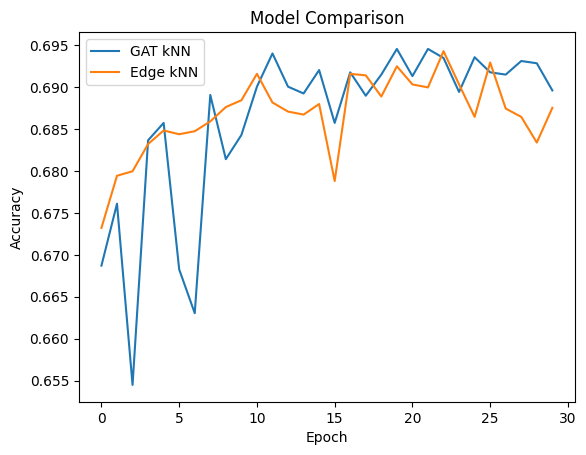

In [17]:
plt.plot(gat_test_knn_acc, label="GAT kNN")
plt.plot(edge_test_knn_acc, label="Edge kNN")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Model Comparison")
plt.show()

In [18]:
from sklearn.metrics import roc_auc_score

def compute_auc(model, loader):
    model.eval()
    y_true = []
    y_scores = []

    for data in loader:
        data = data.to(device)
        out = model(data.x, data.edge_index, data.batch)
        probs = torch.softmax(out, dim=1)[:, 1]

        y_true.extend(data.y.cpu().numpy())
        y_scores.extend(probs.detach().cpu().numpy())

    return roc_auc_score(y_true, y_scores)

print("GAT AUC:", compute_auc(gat_knn, test_loader_knn))
print("EdgeConv AUC:", compute_auc(edge_knn, test_loader_knn))

GAT AUC: 0.7497561932309487
EdgeConv AUC: 0.743184791471098


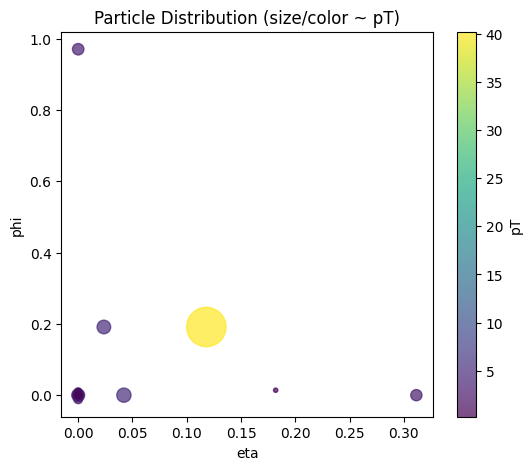

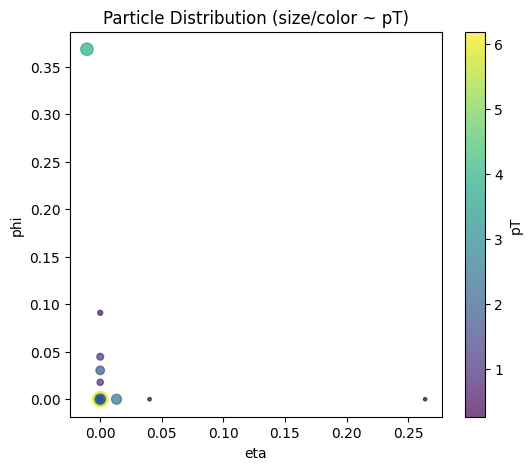

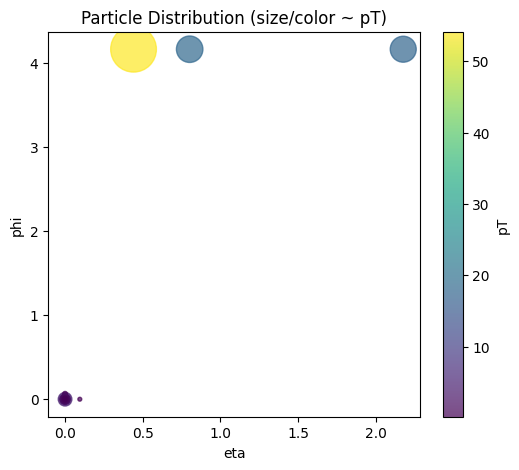

In [19]:
def plot_particles_pt(particles):
    eta = particles[:, 2]
    phi = particles[:, 3]
    pt  = particles[:, 0]

    plt.figure(figsize=(6,5))
    plt.scatter(
        eta,
        phi,
        s=pt * 20,          # size ~ pT
        c=pt,               # color ~ pT
        cmap="viridis",
        alpha=0.7
    )
    plt.colorbar(label="pT")
    plt.xlabel("eta")
    plt.ylabel("phi")
    plt.title("Particle Distribution (size/color ~ pT)")
    plt.show()

batch = next(pf.iter_batches(batch_size=3))
df_batch = batch.to_pandas()

for i in range(len(df_batch)):
    jet = df_batch.iloc[i]["X_jets"]
    particles = jet_to_particles(jet)
    plot_particles_pt(particles)

## Results

| Model     | Accuracy | AUC   |
|----------|---------|-------|
| GAT      | 0.6946  | 0.7498 |
| EdgeConv | 0.6943  | 0.7432 |

## Observations

In this dataset split (run2), both models achieve nearly identical accuracy, with GAT showing a slight advantage in AUC.

Compared to previous runs:
- Run0: EdgeConv performed better
- Run1: GAT performed better
- Run2: Both models perform similarly

## Analysis

Across three independent dataset splits, no single model consistently outperforms the other.

- EdgeConv performs better when local geometric structure is dominant
- GAT performs better when adaptive weighting of particle interactions is beneficial

The results suggest that both models capture complementary aspects of jet physics.

Performance variability across runs indicates sensitivity to underlying data distributions, which is expected in particle physics due to stochastic event generation and detector noise.

## Conclusion

This experiment reinforces that model performance is not consistent across dataset splits.

Both GAT and EdgeConv are effective, but their relative performance depends on the characteristics of the data.

This highlights the importance of evaluating models across multiple datasets for reliable conclusions in scientific machine learning.